Data ready. Shape: (1000, 10)
Risk distribution:
 Risk
0    746
1    254
Name: count, dtype: int64


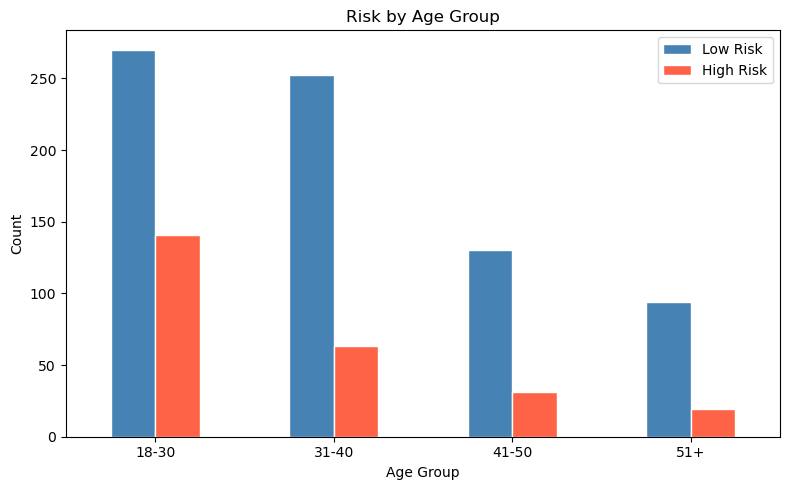

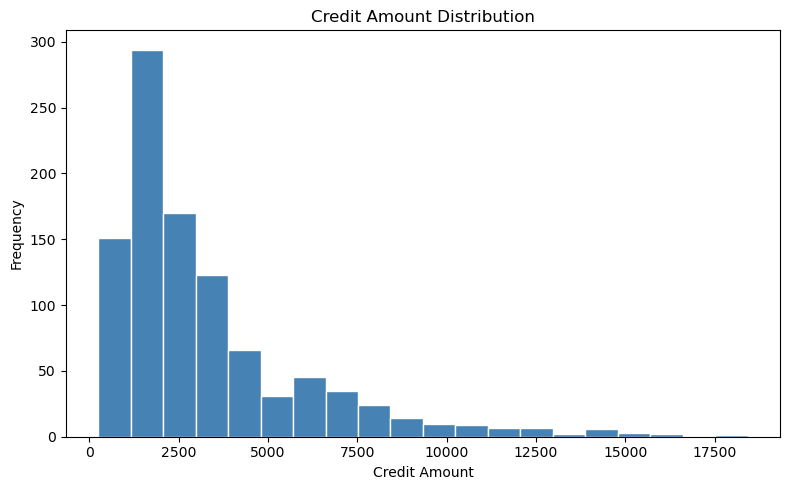

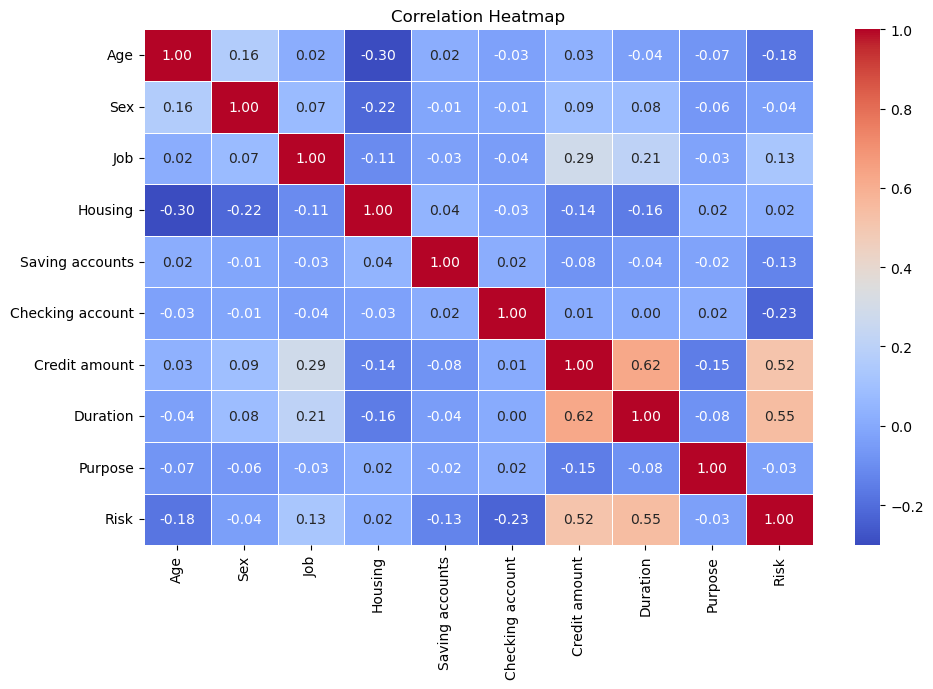

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


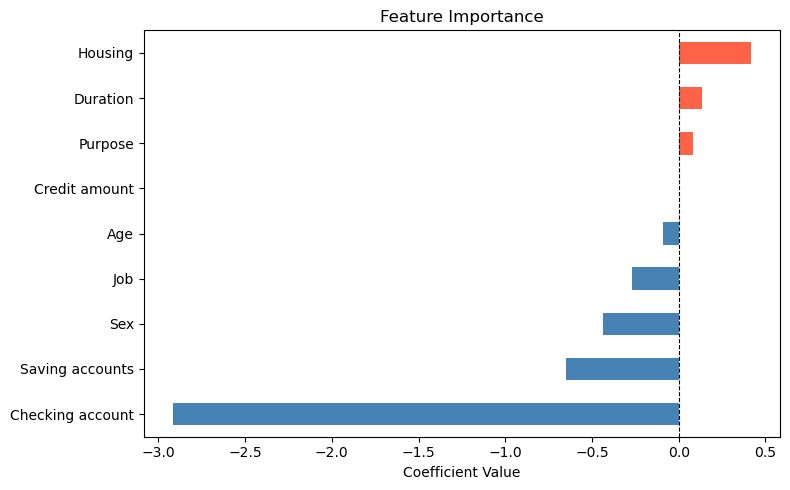

        MODEL PERFORMANCE SUMMARY
  Accuracy  : 93.00%  → overall correct predictions
  Precision : 82.50%  → of predicted high risk, how many truly are
  Recall    : 82.50%  → of actual high risk, how many we caught
  F1 Score  : 82.50%  → balance between precision and recall

── Detailed Classification Report ─────────────────
              precision    recall  f1-score   support

    Low Risk       0.96      0.96      0.96       160
   High Risk       0.82      0.82      0.82        40

    accuracy                           0.93       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.93      0.93      0.93       200



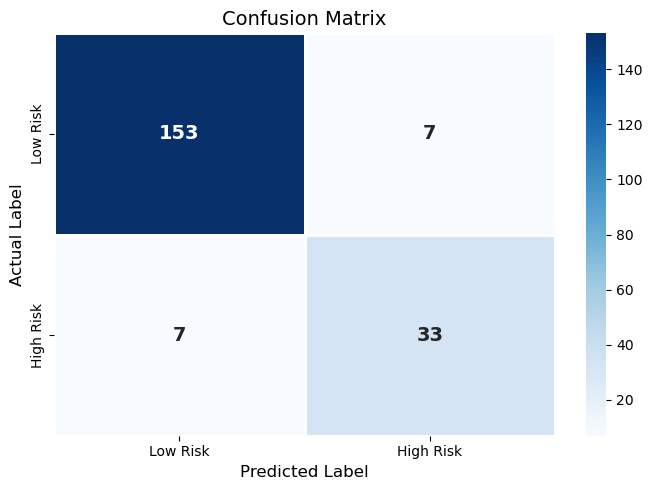


── Confusion Matrix Breakdown ─────────────────────
  True Negatives  (TN): 153  → correctly predicted Low Risk
  False Positives (FP): 7  → predicted High Risk but actually Low Risk
  False Negatives (FN): 7  → predicted Low Risk but actually High Risk
  True Positives  (TP): 33  → correctly predicted High Risk

  In credit risk, False Negatives are the most costly
  (approving a loan for someone who will default)


In [19]:


import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# ── Step 1: Load ──────────────────────────────────────────────────────────────
os.chdir(r"C:\Users\user\Downloads\archive (2)")
df = pd.read_csv("german_credit_data.csv")
df.drop(columns=['Unnamed: 0'], inplace=True)

# ── Step 2: Clean ─────────────────────────────────────────────────────────────
df['Saving accounts']  = df['Saving accounts'].fillna(df['Saving accounts'].mode()[0])
df['Checking account'] = df['Checking account'].fillna(df['Checking account'].mode()[0])
df.drop_duplicates(inplace=True)

le = LabelEncoder()
for col in ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']:
    df[col] = le.fit_transform(df[col])

# ── Step 2b: Create Risk column ───────────────────────────────────────────────
def assign_risk(row):
    score = 0
    if row['Credit amount'] > 7000: score += 2
    if row['Duration'] > 24:        score += 2
    if row['Checking account'] == 0: score += 2
    if row['Saving accounts'] == 0:  score += 1
    if row['Age'] < 25:              score += 1
    return 1 if score >= 4 else 0

df['Risk'] = df.apply(assign_risk, axis=1)
print("Data ready. Shape:", df.shape)
print("Risk distribution:\n", df['Risk'].value_counts())

# ── Step 3: Explore ───────────────────────────────────────────────────────────
df['Age group'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 75],
                         labels=['18-30', '31-40', '41-50', '51+'])

df.groupby('Age group', observed=True)['Risk'].value_counts().unstack().plot(
    kind='bar', figsize=(8, 5), color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Risk by Age Group')
plt.xlabel('Age Group'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.legend(['Low Risk', 'High Risk'])
plt.tight_layout(); plt.show()

df['Credit amount'].plot(kind='hist', bins=20, figsize=(8, 5),
                         color='steelblue', edgecolor='white')
plt.title('Credit Amount Distribution')
plt.xlabel('Credit Amount'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df.drop(columns=['Age group']).corr(numeric_only=True),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

# ── Step 4: Build Model ───────────────────────────────────────────────────────
X = df.drop(columns=['Risk', 'Age group']).select_dtypes(include='number')
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Feature importance
importance = pd.Series(model.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
importance.plot(kind='barh',
                color=['tomato' if v > 0 else 'steelblue' for v in importance])
plt.title('Feature Importance')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout(); plt.show()

# ── Step 5: Evaluate ──────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print("        MODEL PERFORMANCE SUMMARY")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.2%}  → overall correct predictions")
print(f"  Precision : {precision:.2%}  → of predicted high risk, how many truly are")
print(f"  Recall    : {recall:.2%}  → of actual high risk, how many we caught")
print(f"  F1 Score  : {f1:.2%}  → balance between precision and recall")
print("=" * 45)

print("\n── Detailed Classification Report ─────────────────")
print(classification_report(y_test, y_pred,
                            target_names=['Low Risk', 'High Risk']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'],
            linewidths=1, linecolor='white',
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print("\n── Confusion Matrix Breakdown ─────────────────────")
print(f"  True Negatives  (TN): {tn}  → correctly predicted Low Risk")
print(f"  False Positives (FP): {fp}  → predicted High Risk but actually Low Risk")
print(f"  False Negatives (FN): {fn}  → predicted Low Risk but actually High Risk")
print(f"  True Positives  (TP): {tp}  → correctly predicted High Risk")
print("\n  In credit risk, False Negatives are the most costly")
print("  (approving a loan for someone who will default)")
